<a href="https://colab.research.google.com/github/nanopiero/ML_S5_exam_S2_2026/blob/main/Probleme2_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problème 2 — Distillation de connaissance



## Contexte

Dans ce problème, on se propose d’étudier le principe de **distillation de connaissance**.

L’objectif général est le suivant : dans de nombreuses applications industrielles, le **coût principal vient de l’inférence** (nombre de paramètres, latence, consommation énergétique).  
On cherche donc souvent à **améliorer les performances d’un modèle de taille donnée**, sans augmenter sa complexité.

La distillation est une technique permettant d’atteindre cet objectif.

Le principe est d’entraîner un modèle simple (**élève**) à reproduire le comportement d’un modèle plus puissant (**professeur**).  
Le professeur est d’abord entraîné normalement sur les données. Ensuite, ses prédictions sont utilisées comme **cible d’apprentissage** pour l’élève.

L’idée clé est que les sorties d’un modèle entraîné contiennent **plus d’information que les étiquettes dures (one-hot)**.  
La distribution de probabilité produite par le professeur peut révéler des relations entre classes qui ne sont pas visibles dans les labels.

Deux approches simples de distillation sont couramment utilisées :

1. **Régression sur les probabilités du professeur**  
   L’élève apprend à reproduire le vecteur de probabilités produit par le professeur.

2. **Entropie croisée entre distributions**  
   On entraîne l’élève à minimiser l’entropie croisée entre sa distribution de sortie et celle du professeur.

Dans cet exercice, on cherchera à déterminer si un modèle simple peut améliorer ses performances **à capacité fixe** en utilisant l’information fournie par un modèle plus puissant.












# Partie 1 — Un jeu de données jouet

On utilisera le dataset :

**Fashion-MNIST**

Ce dataset contient :

- 60 000 images d’entraînement
- 10 000 images de test
- images **28×28 en niveaux de gris**
- 10 classes d’objets vestimentaires

### Travail demandé

1. Télécharger le dataset.
2. Afficher :
   - la taille du jeu d’entraînement et du jeu de test
   - la liste des classes.
3. Visualiser plusieurs images du dataset avec leur label.

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.63MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.2MB/s]


Taille train set : 60000
Taille test set : 10000
Classes : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


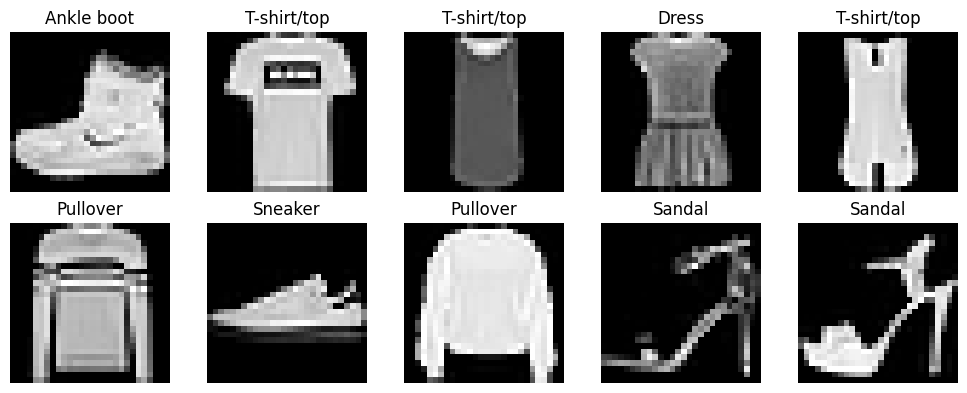

In [ ]:
# Partie 1 : téléchargement et exploration de Fashion-MNIST

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Chargement du dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Informations de base
print("Taille train set :", len(train_dataset))
print("Taille test set :", len(test_dataset))

classes = train_dataset.classes
print("Classes :", classes)

# Visualisation de quelques images
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Partie 2 — Entraînement d’un professeur et d’un élève

Dans cette partie, on entraîne deux modèles en **PyTorch** :

- un modèle puissant (professeur)
- un modèle plus simple (élève)

## Professeur

Le professeur est un **ResNet18**.

Il est entraîné de manière standard :

- loss : **cross-entropy**
- optimisation classique
- évaluation sur le jeu de test.

## Élève

L’élève est un **CNN à m couches convolutives**.

Architecture typique :

- blocs convolution + activation
- pooling occasionnel
- couche finale linéaire vers les 10 classes.

### A noter :

Le choix de **m** est important.

- Si le CNN est **trop simple**, il peut ne pas réussir à apprendre correctement.
- Si le CNN est **trop puissant**, il peut atteindre des performances similaires au ResNet18.

Dans ce cas, la distillation risque d’apporter peu d’information supplémentaire.

On cherchera donc un compromis raisonnable pour **m** afin d’obtenir un modèle significativement plus simple que ResNet18 tout en restant capable d’apprendre le problème.

Comparer ensuite :

- accuracy du professeur
- accuracy de l’élève.


Device: cuda
Paramètres professeur : 11172810
Paramètres élève      : 72442

--- Entraînement professeur ---
epoch 1/10  test_acc=0.899
epoch 2/10  test_acc=0.916
epoch 3/10  test_acc=0.922
epoch 4/10  test_acc=0.910
epoch 5/10  test_acc=0.915
epoch 6/10  test_acc=0.928
epoch 7/10  test_acc=0.924
epoch 8/10  test_acc=0.933
epoch 9/10  test_acc=0.925
epoch 10/10  test_acc=0.929

--- Entraînement élève ---
epoch 1/10  test_acc=0.728
epoch 2/10  test_acc=0.810
epoch 3/10  test_acc=0.813
epoch 4/10  test_acc=0.843
epoch 5/10  test_acc=0.855
epoch 6/10  test_acc=0.847
epoch 7/10  test_acc=0.868
epoch 8/10  test_acc=0.876
epoch 9/10  test_acc=0.879
epoch 10/10  test_acc=0.886


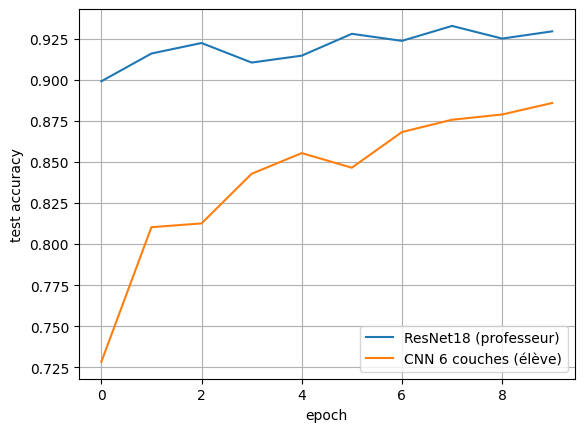


Accuracy finale professeur : 0.9295
Accuracy finale élève     : 0.8859
Écart                     : 0.04359999999999997


In [ ]:
# Correction — Partie 2 : entraînement d’un professeur (ResNet18) et d’un élève (CNN 6 couches)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# Élève : CNN à 6 couches convolutives
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv2d(16,16,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.classifier = nn.Linear(64,10)

    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0),-1)
        return self.classifier(x)

# Professeur : ResNet18 adapté aux images 28x28
def build_resnet18():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1,64,3,stride=1,padding=1,bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features,10)
    return model

teacher = build_resnet18().to(device)
student = SmallCNN().to(device)

# Compte des paramètres
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Paramètres professeur :", count_params(teacher))
print("Paramètres élève      :", count_params(student))

# Évaluation
def evaluate(model):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device),y.to(device)
            logits = model(x)
            pred = logits.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

# Entraînement
def train(model, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(),lr=lr)
    acc_hist = []

    for e in range(epochs):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device),y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits,y)
            loss.backward()
            opt.step()

        acc = evaluate(model)
        acc_hist.append(acc)
        print(f"epoch {e+1}/{epochs}  test_acc={acc:.3f}")

    return acc_hist

print("\n--- Entraînement professeur ---")
teacher_hist = train(teacher)

print("\n--- Entraînement élève ---")
student_hist = train(student)

# Courbes
plt.plot(teacher_hist,label="ResNet18 (professeur)")
plt.plot(student_hist,label="CNN 6 couches (élève)")
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.legend()
plt.grid()
plt.show()

print("\nAccuracy finale professeur :", teacher_hist[-1])
print("Accuracy finale élève     :", student_hist[-1])
print("Écart                     :", teacher_hist[-1]-student_hist[-1])

# Partie 3 — Distillation

On entraîne maintenant **le même CNN élève**, mais en utilisant l’information produite par le professeur.

La méthode de distillation est **libre**.  
Vous pouvez choisir par exemple :

- régression sur les probabilités du professeur
- entropie croisée entre les distributions professeur / élève
- combinaison avec la loss standard.

Précisez votre (ou vos) choix, la manière dont vous l'implémentez et comparez ensuite :

- CNN entraîné normalement
- CNN entraîné par distillation.


### A noter :

Plusieurs situations peuvent apparaître :

1. **Le CNN simple obtient déjà des performances proches du ResNet18.**  
   Dans ce cas, la distillation peut ne pas améliorer significativement les résultats.

2. **Le CNN simple apprend difficilement.**  
   Dans ce cas, il peut être nécessaire d’ajuster :
   - la profondeur du réseau
   - le learning rate
   - le nombre d’epochs.

Si ces situations apparaissent, **il faut simplement le signaler et l’analyser**.  
L’objectif de l’exercice est d’étudier le comportement de la distillation, pas d’obtenir un résultat parfait.

In [ ]:
# Correction — Partie 3 : distillation de l'élève à partir du professeur
# Cette cellule :
# 1) recharge Fashion-MNIST
# 2) définit le professeur (ResNet18) et l'élève (CNN 6 couches)
# 3) entraîne :
#    - le professeur
#    - un élève standard
#    - un élève distillé
# 4) compare les trois courbes d'accuracy test

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --------------------------------------------------
# Dataset
# --------------------------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

# --------------------------------------------------
# Modèles
# --------------------------------------------------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(64, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def build_resnet18():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

teacher = build_resnet18().to(device)
student_standard = SmallCNN().to(device)
student_distilled = SmallCNN().to(device)

# --------------------------------------------------
# Outils
# --------------------------------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def train_supervised(model, train_loader, test_loader, epochs=30, lr=1e-3, name="modèle"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    print(f"\n--- Entraînement supervisé : {name} ---")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"epoch {epoch+1:02d}/{epochs} | test_acc={acc:.4f}")

    return history

def train_distillation(student, teacher, train_loader, test_loader, epochs=30, lr=1e-3,
                       T=3.0, alpha=0.7, name="élève distillé"):
    # alpha : poids de la distillation
    # (1-alpha) : poids de la cross-entropy standard
    ce = nn.CrossEntropyLoss()
    kl = nn.KLDivLoss(reduction="batchmean")
    optimizer = optim.Adam(student.parameters(), lr=lr)
    history = []

    teacher.eval()
    print(f"\n--- Entraînement par distillation : {name} ---")
    for epoch in range(epochs):
        student.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            with torch.no_grad():
                teacher_logits = teacher(x)

            student_logits = student(x)

            loss_hard = ce(student_logits, y)
            loss_soft = kl(
                torch.log_softmax(student_logits / T, dim=1),
                torch.softmax(teacher_logits / T, dim=1)
            ) * (T * T)

            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc = evaluate(student, test_loader)
        history.append(acc)
        print(f"epoch {epoch+1:02d}/{epochs} | test_acc={acc:.4f}")

    return history

# --------------------------------------------------
# Infos modèles
# --------------------------------------------------
print("Paramètres professeur       :", count_params(teacher))
print("Paramètres élève standard   :", count_params(student_standard))
print("Paramètres élève distillé   :", count_params(student_distilled))

# --------------------------------------------------
# Entraînements
# --------------------------------------------------
teacher_hist = train_supervised(
    teacher, train_loader, test_loader,
    epochs=30, lr=1e-3, name="professeur ResNet18"
)

student_standard_hist = train_supervised(
    student_standard, train_loader, test_loader,
    epochs=30, lr=1e-3, name="élève CNN standard"
)

student_distilled_hist = train_distillation(
    student_distilled, teacher, train_loader, test_loader,
    epochs=30, lr=1e-3, T=3.0, alpha=0.7, name="élève CNN distillé"
)

# --------------------------------------------------
# Comparaison finale : trois courbes
# --------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(teacher_hist, label="Professeur (ResNet18)")
plt.plot(student_standard_hist, label="Élève standard")
plt.plot(student_distilled_hist, label="Élève distillé")
plt.xlabel("Epoch")
plt.ylabel("Accuracy test")
plt.title("Comparaison des trois modèles")
plt.grid()
plt.legend()
plt.show()

print("\n--- Résultats finaux ---")
print(f"Professeur (ResNet18) : {teacher_hist[-1]:.4f}")
print(f"Élève standard        : {student_standard_hist[-1]:.4f}")
print(f"Élève distillé        : {student_distilled_hist[-1]:.4f}")
print(f"Gain distillation vs élève standard : {student_distilled_hist[-1] - student_standard_hist[-1]:.4f}")

Device: cuda
Paramètres professeur       : 11172810
Paramètres élève standard   : 72442
Paramètres élève distillé   : 72442

--- Entraînement supervisé : professeur ResNet18 ---
epoch 01/30 | test_acc=0.9001
epoch 02/30 | test_acc=0.9138
epoch 03/30 | test_acc=0.9214
epoch 04/30 | test_acc=0.9229
epoch 05/30 | test_acc=0.9232
epoch 06/30 | test_acc=0.9278
epoch 07/30 | test_acc=0.9234
epoch 08/30 | test_acc=0.9220
epoch 09/30 | test_acc=0.9296
epoch 10/30 | test_acc=0.9279
epoch 11/30 | test_acc=0.9232
epoch 12/30 | test_acc=0.9268
epoch 13/30 | test_acc=0.9260
epoch 14/30 | test_acc=0.9284
epoch 15/30 | test_acc=0.9261
epoch 16/30 | test_acc=0.9262
epoch 17/30 | test_acc=0.9271
epoch 18/30 | test_acc=0.9244
epoch 19/30 | test_acc=0.9275
epoch 20/30 | test_acc=0.9290
epoch 21/30 | test_acc=0.9319
epoch 22/30 | test_acc=0.9256
epoch 23/30 | test_acc=0.9284
epoch 24/30 | test_acc=0.9291
epoch 25/30 | test_acc=0.9291
epoch 26/30 | test_acc=0.9286
epoch 27/30 | test_acc=0.9324
epoch 28/30 

# Conclusion

Comparer les trois modèles :

- professeur (ResNet18)
- élève standard
- élève distillé.

Discuter :

- les différences de performances
- ce que le professeur transmet à l’élève
- dans quelles conditions la distillation peut améliorer un modèle de capacité fixe.